✅ Output image saved at: D:\IPCV\LAB-EXP-13\resultant_img\output_contour.png
✅ Chain code saved at: D:\IPCV\LAB-EXP-13\resultant_img\chain_code.txt


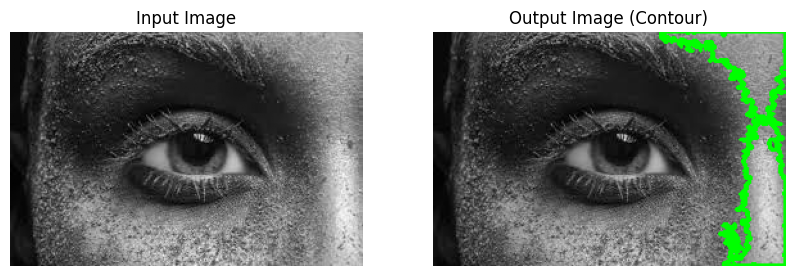

In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

# Input image path
input_path = r"D:\IPCV\LAB-EXP-13\images\1.jpg"

# Output folder and paths
output_folder = r"D:\IPCV\LAB-EXP-13\resultant_img"
os.makedirs(output_folder, exist_ok=True)

output_image_path = os.path.join(output_folder, "output_contour.png")
chain_code_path = os.path.join(output_folder, "chain_code.txt")

# Load image (grayscale)
image = cv2.imread(input_path, 0)

if image is None:
    print("❌ Error: Image not found. Check the path.")
    exit()

# Convert to binary
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

if len(contours) == 0:
    print("❌ No contours found. Try a different image or preprocessing.")
    exit()

# Get largest contour
contour = max(contours, key=cv2.contourArea)

# 8-direction vectors (Freeman Chain Code)
directions = [
    (0, 1), (-1, 1), (-1, 0), (-1, -1),
    (0, -1), (1, -1), (1, 0), (1, 1)
]

def get_chain_code(contour):
    chain_code = []
    
    for i in range(len(contour)):
        x1, y1 = contour[i][0]
        x2, y2 = contour[(i + 1) % len(contour)][0]
        
        dx = x2 - x1
        dy = y2 - y1
        
        for idx, (dyy, dxx) in enumerate(directions):
            if dx == dxx and dy == dyy:
                chain_code.append(idx)
                break
                
    return chain_code

# Generate chain code
chain_code = get_chain_code(contour)

# Convert to color for drawing
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# Draw contour
cv2.drawContours(output_image, [contour], -1, (0, 255, 0), 2)

# Save output image
cv2.imwrite(output_image_path, output_image)

# Save chain code to file
with open(chain_code_path, "w") as f:
    f.write("Chain Code:\n")
    f.write(str(chain_code))

print("✅ Output image saved at:", output_image_path)
print("✅ Chain code saved at:", chain_code_path)

# Display using matplotlib (no GUI error)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output_image[:,:,::-1])  # Convert BGR to RGB
plt.title("Output Image (Contour)")
plt.axis('off')

plt.show()